In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/data.csv', encoding='1251')

pd.set_option('display.max_columns', 40)

pd.set_option('display.float_format', '{:.2f}'.format)

our_cols = ['DR_Dat', 'DR_Tim', 'DR_NChk', 'DR_NDoc', 'DR_Apt', 'DR_NDrugs', 'DR_Kol',
       'DR_CZak', 'DR_CRoz', 'DR_SDisc', 'DR_TPay', 'DR_CDrugs', 'DR_Suppl', 'DR_CDisc', 'DR_BCDisc', 'DR_TabEmpl', 'DR_VZak', 'DR_Pos']

df = df[our_cols]

df.columns = [
    'c_date', 'c_time', 'nchk', 'ndoc', 'apt', 'drug', 'kol',
    'zak', 'roz', 'discount', 'pay_type', 'drug_id', 'suppl', 'disc_id',
    'disc_barcode', 'empl', 'vzak', 'pos'
]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   c_date        4462 non-null   str    
 1   c_time        4462 non-null   str    
 2   nchk          4462 non-null   int64  
 3   ndoc          4462 non-null   int64  
 4   apt           4462 non-null   int64  
 5   drug          4462 non-null   str    
 6   kol           4462 non-null   float64
 7   zak           4462 non-null   float64
 8   roz           4462 non-null   float64
 9   discount      4462 non-null   float64
 10  pay_type      4462 non-null   int64  
 11  drug_id       4462 non-null   int64  
 12  suppl         4462 non-null   str    
 13  disc_id       1765 non-null   float64
 14  disc_barcode  1765 non-null   float64
 15  empl          4462 non-null   int64  
 16  vzak          4462 non-null   int64  
 17  pos           4462 non-null   float64
dtypes: float64(7), int64(7), str(4)
memory 

In [4]:
df.describe()

,nchk,ndoc,apt,kol,zak,roz,discount,pay_type,drug_id,disc_id,disc_barcode,empl,vzak,pos
count,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,1765.00,1765.00,4462.00,4462.00,4462.00
mean,4903.14,10842995.33,10.84,1.03,241.64,306.05,10.56,16.90,259227.09,156.56,200005828567.16,91.74,1.04,2.68
std,1839.70,6107181.40,6.11,0.54,454.56,532.17,31.37,1.45,299073.90,327.36,4942136.81,108.08,0.18,2.75
min,1698.00,2004595.00,2.00,0.01,0.01,0.01,0.00,15.00,3.00,9.00,200000000022.00,25.00,1.00,1.00
25%,4187.00,6003620.00,6.00,1.00,36.64,52.00,0.00,15.00,29060.00,9.00,200000000022.00,37.00,1.00,1.00
50%,4877.50,11007039.00,11.00,1.00,103.78,137.00,0.00,18.00,187304.00,9.00,200010003934.00,53.00,1.00,2.00
75%,5472.75,18002536.00,18.00,1.00,299.06,391.75,7.00,18.00,377589.00,35.00,200010020692.00,123.00,1.00,3.00
max,8490.00,18002543.00,18.00,20.00,11851.13,12345.00,650.00,18.00,1504498.00,941.00,200010027972.00,605.00,2.00,24.00


In [5]:
df.apt.value_counts()

apt
18    1207
2      979
11     870
6      511
13     322
17     243
15     177
7      153
Name: count, dtype: int64

In [6]:
df['apt'].value_counts()

apt
18    1207
2      979
11     870
6      511
13     322
17     243
15     177
7      153
Name: count, dtype: int64

In [7]:
df['apt'].value_counts(normalize=True)

apt
18   0.27
2    0.22
11   0.19
6    0.11
13   0.07
17   0.05
15   0.04
7    0.03
Name: proportion, dtype: float64

<Axes: >

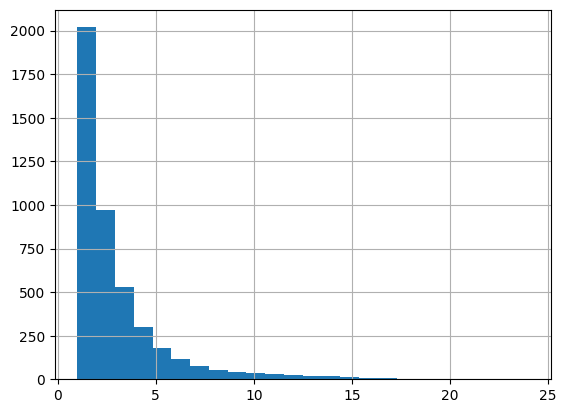

In [8]:
df.pos.hist(bins=24)

<Axes: >

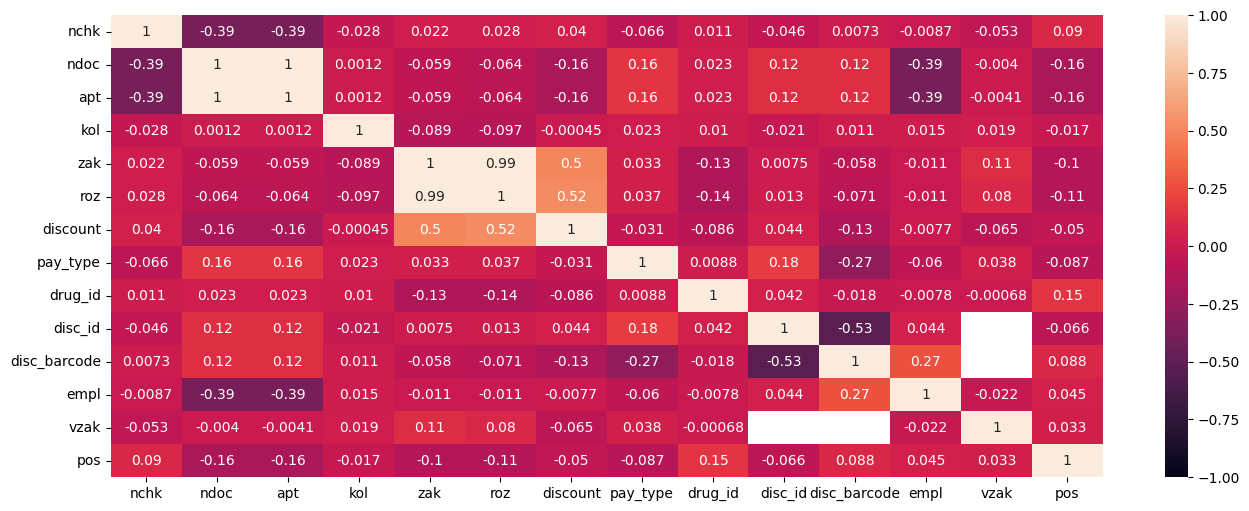

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
sns.heatmap(df.corr(numeric_only=True), vmax=1, vmin=-1, annot=True)

In [10]:
df['hour'] = pd.to_datetime(df['c_time']).dt.hour

df['hour']

/tmp/ipykernel_96807/1028421019.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['c_time']).dt.hour


0       10
1       10
2       10
3       10
4       10
        ..
4457    21
4458    21
4459    21
4460    21
4461    21
Name: hour, Length: 4462, dtype: int32

In [11]:
gr = df.groupby(['hour'])['kol'].agg(sum)

#hour - индекс
gr

hour
8     20.10
9    236.50
10   361.65
11   326.55
12   311.59
13   422.80
14   358.30
15   432.97
16   375.88
17   375.45
18   457.50
19   419.29
20   388.57
21    97.71
22     1.00
Name: kol, dtype: float64

<Axes: ylabel='kol'>

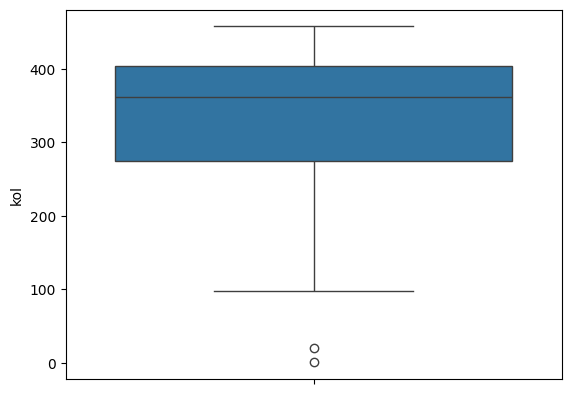

In [12]:
sns.boxplot(gr)

In [13]:
a = df.groupby(['c_date', 'nchk'])[['kol', 'roz', 'zak']].agg({
    'kol' : sum,
    'roz' : ['sum', 'max'],
    'zak' : sum
})

a

kol     roz           zak
                  sum     sum    max    sum
c_date     nchk                            
2022-08-11 1698  1.00  463.00 463.00 342.30
           1699  1.00  720.00 720.00 545.27
           1700  1.00   60.00  60.00  36.68
           1701  4.00  955.00 443.00 756.12
           1702  1.00   94.00  94.00  76.55
...               ...     ...    ...    ...
2022-08-12 8486  1.00  460.00 460.00 302.07
           8487  1.00  476.00 476.00 396.66
           8488  1.00  220.00 220.00 187.84
           8489 18.00 1089.00 180.00 778.61
           8490  3.00  869.00 775.00 626.13

[1941 rows x 4 columns]

In [14]:
a.index # Теперь это мультииндекс (несколько переменных в индексе)

MultiIndex([('2022-08-11', 1698),
            ('2022-08-11', 1699),
            ('2022-08-11', 1700),
            ('2022-08-11', 1701),
            ('2022-08-11', 1702),
            ('2022-08-11', 1703),
            ('2022-08-11', 1704),
            ('2022-08-11', 1705),
            ('2022-08-11', 1706),
            ('2022-08-11', 1707),
            ...
            ('2022-08-12', 8481),
            ('2022-08-12', 8482),
            ('2022-08-12', 8483),
            ('2022-08-12', 8484),
            ('2022-08-12', 8485),
            ('2022-08-12', 8486),
            ('2022-08-12', 8487),
            ('2022-08-12', 8488),
            ('2022-08-12', 8489),
            ('2022-08-12', 8490)],
           names=['c_date', 'nchk'], length=1941)

In [15]:
a.reset_index() #Сбрасывает индекс, вместо мультииндекса - числовое значение

c_date  nchk   kol     roz           zak
                         sum     sum    max    sum
0     2022-08-11  1698  1.00  463.00 463.00 342.30
1     2022-08-11  1699  1.00  720.00 720.00 545.27
2     2022-08-11  1700  1.00   60.00  60.00  36.68
3     2022-08-11  1701  4.00  955.00 443.00 756.12
4     2022-08-11  1702  1.00   94.00  94.00  76.55
...          ...   ...   ...     ...    ...    ...
1936  2022-08-12  8486  1.00  460.00 460.00 302.07
1937  2022-08-12  8487  1.00  476.00 476.00 396.66
1938  2022-08-12  8488  1.00  220.00 220.00 187.84
1939  2022-08-12  8489 18.00 1089.00 180.00 778.61
1940  2022-08-12  8490  3.00  869.00 775.00 626.13

[1941 rows x 6 columns]

In [16]:
sum_dict = df.groupby(['c_date', 'empl'])[['zak', 'roz']].agg(sum)

sum_dict

zak       roz
c_date     empl                   
2022-08-11 25   72004.24  93030.00
           30   90350.41 111916.97
           36   62425.32  77368.03
           47   68458.33  86626.01
           50   72304.41  90830.01
           53   37727.08  48746.00
           54   52880.81  67517.08
           123  88926.21 116678.03
           205  49904.42  59471.00
           605  28699.65  36954.01
2022-08-12 37   92688.93 118091.37
           48   72773.60  93032.02
           54   65852.52  83229.05
           110  89126.47 113275.05
           123  99298.80 124231.66
           205  34772.17  44595.01

In [17]:
sum_dict['revenue'] = sum_dict['roz'] - sum_dict['zak']

sum_dict

zak       roz  revenue
c_date     empl                            
2022-08-11 25   72004.24  93030.00 21025.76
           30   90350.41 111916.97 21566.56
           36   62425.32  77368.03 14942.71
           47   68458.33  86626.01 18167.68
           50   72304.41  90830.01 18525.60
           53   37727.08  48746.00 11018.92
           54   52880.81  67517.08 14636.27
           123  88926.21 116678.03 27751.82
           205  49904.42  59471.00  9566.58
           605  28699.65  36954.01  8254.36
2022-08-12 37   92688.93 118091.37 25402.44
           48   72773.60  93032.02 20258.42
           54   65852.52  83229.05 17376.53
           110  89126.47 113275.05 24148.58
           123  99298.80 124231.66 24932.86
           205  34772.17  44595.01  9822.84

In [18]:
sum_dict_apply = df.groupby(['c_date', 'empl'])[['zak', 'roz', 'kol']].apply(lambda x: sum(x['kol']*(x['roz'] - x['zak'])))

sum_dict_apply

c_date      empl
2022-08-11  25     20642.29
            30     20328.67
            36     14090.04
            47     16983.79
            50     17384.41
            53     10056.40
            54     13981.47
            123    23756.34
            205     9724.19
            605     8341.71
2022-08-12  37     22613.80
            48     19244.82
            54     16801.83
            110    22711.32
            123    23167.41
            205     8873.30
dtype: float64

In [19]:
import numpy as np

df.groupby(['c_date', 'drug'])[['roz', 'kol']].agg({
    'roz' : np.mean,
    'kol' : np.sum
})

roz  kol
c_date     drug                                                           
2022-08-11 911-ГЕЛЬ-БАЛЬЗАМ Д/СУСТАВОВ ОКОПНИК 100МЛ. ТУБА     111.00 1.00
           911-ГЕЛЬ-БАЛЬЗАМ Д/СУСТАВОВ САБЕЛЬНИК 100МЛ.        104.00 1.00
           L-ТИРОКСИН 150МКГ. №100 ТАБ. /БЕРЛИН ХЕМИ/          170.00 1.00
           L-ТИРОКСИН 50МКГ. №50 ТАБ. /БЕРЛИН ХЕМИ/             93.00 1.00
           ZD ТЕЙМУРОВА СПРЕЙ Д/НОГ П/ПОТА И ЗАПАХА 150МЛ....   96.00 1.00
...                                                               ...  ...
2022-08-12 ЭУФИЛЛИН 150МГ. №30 ТАБ. /ФАРМСТАНДАРТ/              31.00 2.00
           ЮНИЭНЗИМ С МПС №20 ТАБ. П/О                         141.00 1.00
           Я ЗАБОЧУСЬ О ЗДОРОВЬЕ ТРАВЯН.КОФЕ КОФЕЙНЫЙ НАПИ...  145.00 1.00
           ЯНТАРНАЯ К-ТА ФОРП 100МГ. №10 ТАБ.                   14.00 2.00
           ЯРИНА №21 ТАБ. П/П/О                               1292.00 1.00

[2304 rows x 2 columns]

In [37]:
df['rounded_roz'] = df['roz'].apply(lambda x: round(x, -2))

df['rounded_roz']

0      100.00
1        0.00
2      200.00
3      200.00
4      800.00
        ...  
4457   100.00
4458   100.00
4459   400.00
4460   400.00
4461   300.00
Name: rounded_roz, Length: 4462, dtype: float64

In [21]:
b = df.groupby(['c_date', 'rounded_roz'])[['kol']].agg(np.sum).reset_index()

b

,c_date,rounded_roz,kol
0,2022-08-11,0.00,770.00
1,2022-08-11,100.00,742.00
2,2022-08-11,200.00,328.43
3,2022-08-11,300.00,196.20
4,2022-08-11,400.00,133.00
...,...,...,...
68,2022-08-12,4400.00,1.00
69,2022-08-12,5000.00,1.00
70,2022-08-12,5800.00,1.00
71,2022-08-12,10200.00,1.00


<Axes: xlabel='rounded_roz', ylabel='kol'>

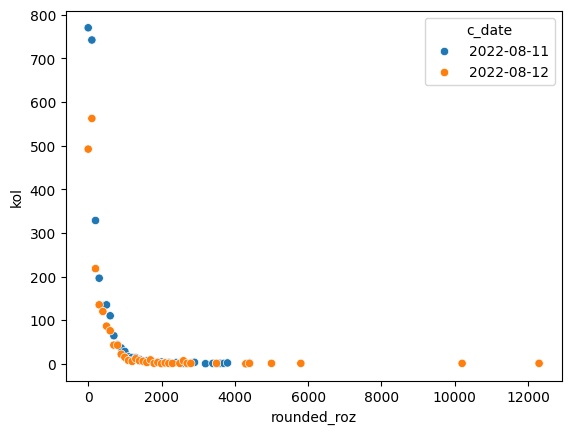

In [22]:
sns.scatterplot(x=b.rounded_roz, y=b.kol, hue=b.c_date)

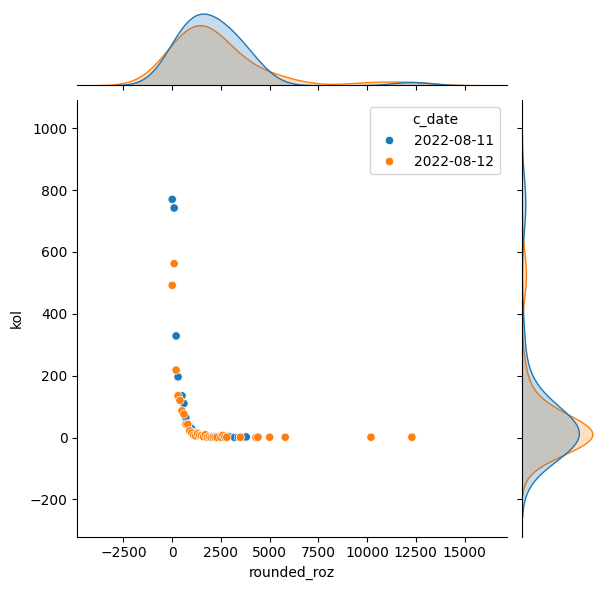

In [23]:
sns.jointplot(x=b.rounded_roz, y=b.kol, hue=b.c_date)

In [24]:
c = df.groupby(['c_date', 'apt', 'empl', 'pay_type'])[['kol']].agg(sum).reset_index()

c

,c_date,apt,empl,pay_type,kol
0,2022-08-11,2,123,15,151.05
1,2022-08-11,2,123,18,164.13
2,2022-08-11,2,205,15,65.11
3,2022-08-11,2,205,18,66.00
4,2022-08-11,6,25,15,95.00
5,2022-08-11,6,25,18,142.53
6,2022-08-11,7,605,15,67.04
7,2022-08-11,7,605,18,101.85
8,2022-08-11,11,30,15,179.00
9,2022-08-11,11,30,18,310.48


In [25]:
c.pivot_table(values='kol', index=['c_date', 'apt', 'empl'], columns=['pay_type']) # Сводная таблицы (денормализация)

pay_type                15     18
c_date     apt empl              
2022-08-11 2   123  151.05 164.13
               205   65.11  66.00
           6   25    95.00 142.53
           7   605   67.04 101.85
           11  30   179.00 310.48
           13  50   180.40 151.78
           15  53    51.98 142.10
           17  36    54.73 186.94
           18  47    89.04 236.24
               54    65.10 198.77
2022-08-12 2   123  210.50 152.72
               205   88.41  80.19
           6   37    72.92 207.89
           11  110   91.67 363.08
           18  48   134.79 222.65
               54    64.10 197.65

In [26]:
d = df.pivot_table(values='roz', index=['c_date', 'apt', 'empl'], columns=['pay_type'], aggfunc=sum)

d = d.reset_index()

d

pay_type,c_date,apt,empl,15,18
0,2022-08-11,2,123,55981.01,60697.02
1,2022-08-11,2,205,27403.00,32068.00
2,2022-08-11,6,25,27402.00,65628.00
3,2022-08-11,7,605,17618.00,19336.01
4,2022-08-11,11,30,38692.32,73224.65
5,2022-08-11,13,50,44746.00,46084.01
6,2022-08-11,15,53,20155.00,28591.00
7,2022-08-11,17,36,20890.00,56478.03
8,2022-08-11,18,47,25685.01,60941.00
9,2022-08-11,18,54,12118.00,55399.08


In [27]:
pd.melt(d, id_vars=['c_date', 'apt', 'empl'], value_vars=[15, 18], var_name='p_type')

,c_date,apt,empl,p_type,value
0,2022-08-11,2,123,15,55981.01
1,2022-08-11,2,205,15,27403.00
2,2022-08-11,6,25,15,27402.00
3,2022-08-11,7,605,15,17618.00
4,2022-08-11,11,30,15,38692.32
5,2022-08-11,13,50,15,44746.00
6,2022-08-11,15,53,15,20155.00
7,2022-08-11,17,36,15,20890.00
8,2022-08-11,18,47,15,25685.01
9,2022-08-11,18,54,15,12118.00


In [28]:
df.iloc[2, 5] # 3 строка 6 столбец

'СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ 125МЛ.'

In [29]:
df.iloc[:5, 5] # срез до 5 строки, 5 столбец

0    ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...
1              ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.
2    СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...
3    СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...
4                     ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/
Name: drug, dtype: str

In [30]:
df.loc[2:5, ['zak', 'roz']]

,zak,roz
2,132.69,209.00
3,133.65,210.00
4,709.95,787.00
5,152.90,182.00


In [31]:
df.at[2, "zak"] #Точное перечисление строки и столбца, только одно значение перечисления (смысле не имеет by the way)

np.float64(132.69)

In [32]:
df.iat[2, 5]

'СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ 125МЛ.'

In [33]:
df[(df['kol'] > 5) | (df['roz'] > 2000)] # Фильтрация ИЛИ (|), И (&)

,c_date,c_time,nchk,ndoc,apt,drug,kol,zak,roz,discount,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos,hour,rounded_roz
27,2022-08-11,11:50:16,2184,2004598,2,АКАТИНОЛ МЕМАНТИН 20МГ. №28 ТАБ. П/П/О /МЕРЦ Ф...,1.00,2545.84,2824.00,141.00,15,153467,ВИТТА КОМПАНИ ООО,9.00,200010014079.00,205,1,1.00,11,2800.00
29,2022-08-11,11:50:16,2184,2004598,2,ПРАДАКСА 110МГ. №60 КАПС. /БЕРИНГЕР/,1.00,3076.03,3432.00,171.00,15,154600,Протек,9.00,200010014079.00,205,1,5.00,11,3400.00
45,2022-08-11,13:10:54,2192,2004598,2,ЦЕФАЛИ АППАРАТ Д/ТЕРАПИИ МИГРЕНИ С ПРИНАДЛ.,1.00,11851.13,12345.00,0.00,18,455413,Протек,NaN,NaN,205,2,1.00,13,12300.00
62,2022-08-11,14:47:12,2201,2004598,2,ДЖАРДИНС 10МГ. №30 ТАБ. П/П/О /БЕРИНГЕР/,1.00,2669.94,2945.00,147.00,15,296849,Катрен г.Химки,9.00,200010024690.00,205,1,1.00,14,2900.00
65,2022-08-11,14:52:33,2203,2004598,2,"АКСАМОН 15МГ/МЛ. 1МЛ. №10 Р-Р Д/В/М,П/К АМП.",1.00,1559.37,2106.00,147.00,15,254247,Здравсервис,9.00,200010018590.00,205,1,1.00,14,2100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3967,2022-08-12,16:33:37,4368,18002543,18,КРЕСТОР 5МГ. №28 ТАБ. П/П/О,1.00,1848.83,2275.00,0.00,18,151718,Фармкомплект ООО,NaN,NaN,54,1,1.00,16,2300.00
3983,2022-08-12,17:02:34,4375,18002543,18,СОЛГАР ТРОЙНАЯ ОМЕГА-3 ЭПК/ДГК 950МГ. №50 КАПС...,1.00,1944.66,2529.00,0.00,18,168640,Здравсервис,NaN,NaN,54,1,3.00,17,2500.00
4057,2022-08-12,19:29:31,4422,18002543,18,СОЛКОСЕРИЛ 20Г. ГЕЛЬ Д/НАРУЖ.ПРИМ. ТУБА,1.00,3778.85,4422.00,0.00,18,1131,Авеста,NaN,NaN,54,1,3.00,19,4400.00
4058,2022-08-12,19:29:31,4422,18002543,18,ВИАГРА 100МГ. №12 ТАБ. П/П/О,1.00,8706.40,10187.00,0.00,18,353730,ГК Надежда Фарм,NaN,NaN,54,1,1.00,19,10200.00


In [34]:
df[~df.loc[:, 'pay_type'].isin([15, 20])]

,c_date,c_time,nchk,ndoc,apt,drug,kol,zak,roz,discount,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos,hour,rounded_roz
0,2022-08-11,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925.00,200000000492.00,205,1,1.00,10,100.00
4,2022-08-11,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925.00,200000000492.00,205,1,1.00,10,800.00
5,2022-08-11,10:40:38,2176,2004598,2,БИСОПРОЛОЛ 5МГ. №60 ТАБ. П/П/О /ВЕРТЕКС/,1.00,152.90,182.00,9.00,18,187304,Пульс,9.00,200010001947.00,205,1,1.00,10,200.00
6,2022-08-11,10:40:38,2176,2004598,2,ТРИХОПОЛ 250МГ. №20 ТАБ. /ПОЛЬФАРМА/,1.00,67.94,85.00,4.00,18,1261,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,9.00,200010001947.00,205,1,2.00,10,100.00
7,2022-08-11,10:52:52,2177,2004598,2,НОРВАСК 5МГ. №30 ТАБ. /ПФАЙЗЕР/АПДЖОН/,1.00,157.76,189.00,9.00,18,2566,Катрен г.Химки,9.00,200010013331.00,205,1,3.00,10,200.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4456,2022-08-12,21:39:23,5689,18002542,18,АЛЬБАДЕНТ ОСВЕЖИТЕЛЬ Д/РТА ЛИМОН 35МЛ. СПРЕЙ,1.00,62.34,97.00,0.00,18,28488,Здравсервис,NaN,NaN,48,1,1.00,21,100.00
4457,2022-08-12,21:40:17,5690,18002542,18,КЕТОРОЛ ЭКСПРЕСС 10МГ. №20 ТАБ. ДИСПЕРГ. /Д-Р ...,1.00,47.88,75.00,0.00,18,463100,ГРАНД КАПИТАЛ СМОЛЕНСК ООО ФК,NaN,NaN,48,1,1.00,21,100.00
4458,2022-08-12,21:40:59,5691,18002542,18,АНТИПОЛИЦАЙ ВАЙТ №6 ТАБ.,1.00,59.51,93.00,0.00,18,112158,Протек,NaN,NaN,48,1,1.00,21,100.00
4459,2022-08-12,21:43:48,5692,18002542,18,СИЛДЕНАФИЛ-СЗ 50МГ. №10 ТАБ. П/П/О /СЕВЕРНАЯ З...,1.00,297.74,396.00,0.00,18,260990,Авеста,NaN,NaN,48,1,1.00,21,400.00


In [35]:
pd.DataFrame({
    'a' : [1, 2, None, 4, None],
    'b' : [1, 2, 3, 4, 5]
}).isnull().any()

a     True
b    False
dtype: bool

In [36]:
m = {
    'Обычный' : 'S1mple',
    'Интернет' : 'W3b'
}

df['vzak'].map(m)

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
4457    NaN
4458    NaN
4459    NaN
4460    NaN
4461    NaN
Name: vzak, Length: 4462, dtype: str